# Part II - Commuters vs. Casual Riders: What Ford GoBike's February 2019 Trip Data Shows
## By Fahad Masood Reda - Udacity Data Analyst Nanodegree Project - 2026

## Investigation Overview

This presentation explores 183,412 trips taken on the Ford GoBike (Bay Wheels) bike-share system in the San Francisco Bay Area during February 2019, to answer one guiding question: **do Subscribers and Customers use the system in fundamentally different ways?**

## Dataset Overview and Executive Summary

Each row in the dataset is a single bike trip, with its duration, start/end time and station, and information about the rider, including whether they are a **Subscriber** (paying member) or a **Customer** (casual, pay-per-ride user).

**Key insights:**
- Subscribers make up 89.2% of all trips, but take much shorter trips than Customers (median 8.2 vs. 13.2 minutes).
- Weekday usage shows a clear two-peak commute pattern around 8am and 5pm; this pattern is far weaker on weekends.
- Only 15.5% of Subscriber trips happen on a weekend, compared to 28.4% of Customer trips.

Together, these patterns show that **Subscribers primarily use the system for short, weekday commute trips, while Customers use it more for longer, leisure-oriented trips.**

In [1]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

# suppress warnings from final output
import warnings
warnings.simplefilter('ignore')

In [2]:
# load in the dataset into a pandas dataframe and engineer the same features used
# during exploration (duration in minutes, day of week, hour, weekend flag)
df = pd.read_csv('201902-fordgobike-tripdata.csv')

df['start_time'] = pd.to_datetime(df['start_time'])
df['duration_min'] = df['duration_sec'] / 60

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['start_time'].dt.day_name(), categories=day_order, ordered=True)
df['hour'] = df['start_time'].dt.hour
df['is_weekend'] = df['start_time'].dt.dayofweek >= 5

df.shape

(183412, 20)

## Weekday trips follow a clear commute pattern; weekend trips don't

The heatmap below counts trips by day of week and hour of day. Two bright bands stand out on Monday-Friday, around 8am and 5pm — classic commute times. Saturday and Sunday show no such peaks; usage is lower and spread more evenly across the day.

Text(0.5, 1.0, 'Trip Counts by Day of Week and Hour of Day, February 2019')

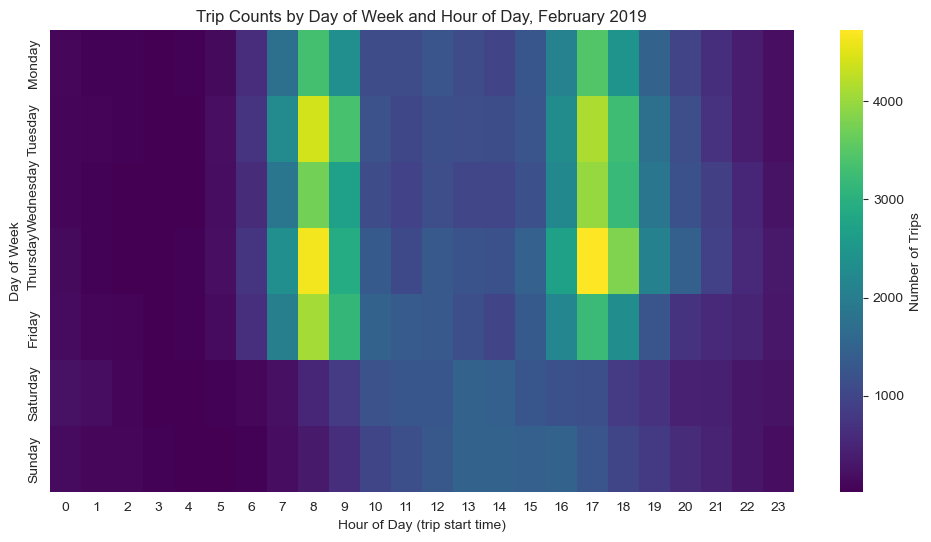

In [3]:
heat_data = df.pivot_table(index='day_of_week', columns='hour', values='duration_sec', aggfunc='count')

plt.figure(figsize=(12, 6))
sns.heatmap(heat_data, cmap='viridis', cbar_kws={'label': 'Number of Trips'})
plt.xlabel('Hour of Day (trip start time)')
plt.ylabel('Day of Week')
plt.title('Trip Counts by Day of Week and Hour of Day, February 2019')


## Customers take much longer trips than Subscribers

Trip duration (shown here on a log scale, since it's heavily right-skewed) is much higher for Customers than for Subscribers. The median Subscriber trip is 8.2 minutes, versus 13.2 minutes for Customers, and Customers also have a much heavier tail of very long trips.

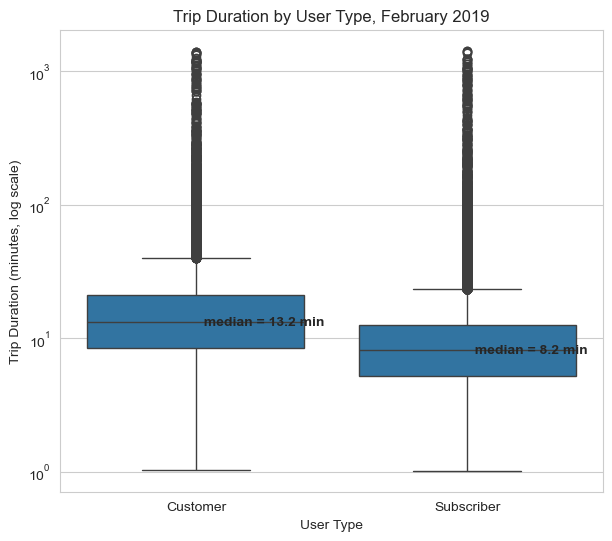

In [4]:
medians = df.groupby('user_type')['duration_min'].median()

plt.figure(figsize=(7, 6))
ax = sns.boxplot(data=df, x='user_type', y='duration_min', color=sns.color_palette()[0])
plt.yscale('log')
plt.xlabel('User Type')
plt.ylabel('Trip Duration (minutes, log scale)')
plt.title('Trip Duration by User Type, February 2019')

# annotate each box with its median duration
for i, ut in enumerate(medians.index):
    ax.text(i, medians[ut], f'  median = {medians[ut]:.1f} min', va='center', fontweight='bold')


## Subscribers ride during the week; Customers spread more evenly across the week

Finally, comparing the two user types' trip counts by day of week directly: Subscriber trips drop off sharply on Saturday and Sunday, while Customer trips fall much less on weekends. Only 15.5% of Subscriber trips happen on a weekend, compared to 28.4% of Customer trips — supporting the idea that Subscribers are largely weekday commuters, while Customers are a more leisure-driven, week-agnostic group of riders.

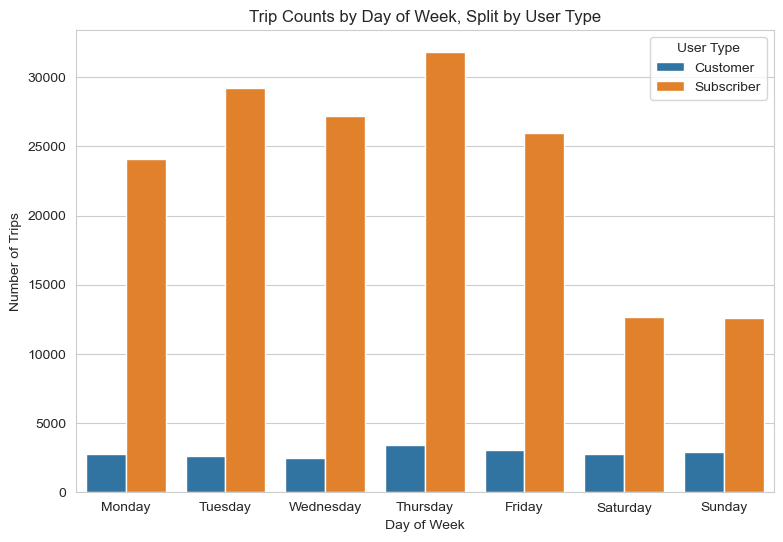

In [5]:
plt.figure(figsize=(9, 6))
sns.countplot(data=df, x='day_of_week', hue='user_type')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.title('Trip Counts by Day of Week, Split by User Type')
plt.legend(title='User Type')


### The End of this Analysis
